In [1]:
import sys

from pathlib import Path



ROOT = Path.cwd().resolve()

if ROOT.name == "Notebooks":

    ROOT = ROOT.parent

if str(ROOT) not in sys.path:

    sys.path.insert(0, str(ROOT))



import os

import json

import importlib



from dotenv import load_dotenv



load_dotenv(ROOT / ".env")



import Classes.helper_classes as helper_classes

import Classes.sql_chunk_classes as sql_chunk_classes



helper_classes = importlib.reload(helper_classes)

sql_chunk_classes = importlib.reload(sql_chunk_classes)



SQLLogicalChunkParser = sql_chunk_classes.SQLLogicalChunkParser



HF_TOKEN = os.environ.get("HF_TOKEN")

MODEL = os.environ.get("MODEL_NAME", "Qwen/Qwen3-Coder-30B-A3B-Instruct")

PROVIDER = os.environ.get("PROVIDER", "scaleway")



if HF_TOKEN:

    print(f"HF_TOKEN loaded: ...{HF_TOKEN[-6:]}")

else:

    print("HF_TOKEN not set; only deterministic preparse() is available.")

print(f"Model: {MODEL} ({PROVIDER})")

/Users/nikolajabramov/PycharmProjects/llm4lineage/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:27: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


HF_TOKEN loaded: ...OrZWkc
Model: Qwen/Qwen3-Coder-Next (novita)


In [2]:
data_path = ROOT / "data" / "SQL.txt"
if not data_path.exists():
    raise FileNotFoundError(f"Could not find {data_path}")

raw_sql = data_path.read_text(encoding="utf-8")
statements = [s.strip() for s in raw_sql.split(";") if s.strip()]

print(f"Loaded {len(raw_sql):,} characters from {data_path}")
print(f"Detected {len(statements)} SQL statement(s)")
print("\nFirst statement preview:\n")
print(statements[0][:1200])

Loaded 17,834 characters from /Users/nikolajabramov/PycharmProjects/llm4lineage/data/SQL.txt
Detected 1 SQL statement(s)

First statement preview:

INSERT INTO s_grnplm_vd_t_bvd_db_dmslcl.d_agr_cred  SELECT agr.agr_cred_id,
    agr.prnt_agr_cred_id,
    agr.info_system_id,
    agr.agr_num,
    agr.grntee_agr_num,
    agr.signed_dt,
    agr.issue_crncy_id,
    agr.eks_overdraft_flag,
    agr.agr_regls_type_id,
        CASE
            WHEN (agr.eks_issue_dt IS NOT NULL) THEN agr.eks_issue_dt
            WHEN ((agr.agr_cred_type_cd = '1'::text) AND (agr.eks_transhes_issue_dt IS NOT NULL)) THEN agr.eks_transhes_issue_dt
            ELSE aco_fst_iss.optn_issue_dt
        END AS issue_dt,
    agr.close_dt,
    agr.expiration_dt,
    agr.host_agr_cred_id,
    agr.host_crm_id,
    agr.eks_agr_cred_type_id,
    agr.agr_frame_id,
    agr.eks_rvlng_flag,
    agr.issue_int_org_id,
    agr.multi_crncy_flag,
    agr.eks_old_restruct_cnt,
    agr.eks_old_prolong_cnt,
    agr.eks_contract_expiration_

In [3]:
chunk_parser = SQLLogicalChunkParser(
    model=MODEL,
    provider=PROVIDER,
    hf_token=HF_TOKEN,
    max_new_tokens=4096,
    temperature=0.0,
    max_retries=2,
)

print("SQLLogicalChunkParser initialized")

SQLLogicalChunkParser initialized


In [4]:
# Deterministic parse (no LLM) — chunks + links only
sql_to_test = statements[0]

preparse_result = chunk_parser.preparse(sql=sql_to_test, dialect=None)

print("Deterministic preparse succeeded")
print("Chunks:", len(preparse_result.get("chunks", [])))
print("Links:", len(preparse_result.get("links", [])))
if preparse_result.get("warnings"):
    print("\nWarnings:")
    for warning in preparse_result["warnings"]:
        print("-", warning)

Deterministic preparse succeeded
Chunks: 4
Links: 5


In [5]:
# Inspect chunks and links
print(json.dumps(preparse_result.get("chunks", []), indent=2)[:4000])
print("\nLinks:")
print(json.dumps(preparse_result.get("links", []), indent=2))

[
  {
    "id": "d_agr_cred",
    "name": "d_agr_cred",
    "chunk_type": "target",
    "sql": "d_agr_cred"
  },
  {
    "id": "branch_0",
    "name": "branch_0",
    "chunk_type": "query",
    "sql": "SELECT agr.agr_cred_id, agr.prnt_agr_cred_id, agr.info_system_id, agr.agr_num, agr.grntee_agr_num, agr.signed_dt, agr.issue_crncy_id, agr.eks_overdraft_flag, agr.agr_regls_type_id, CASE WHEN (NOT agr.eks_issue_dt IS NULL) THEN agr.eks_issue_dt WHEN ((agr.agr_cred_type_cd = CAST('1' AS TEXT)) AND (NOT agr.eks_transhes_issue_dt IS NULL)) THEN agr.eks_transhes_issue_dt ELSE aco_fst_iss.optn_issue_dt END AS issue_dt, agr.close_dt, agr.expiration_dt, agr.host_agr_cred_id, agr.host_crm_id, agr.eks_agr_cred_type_id, agr.agr_frame_id, agr.eks_rvlng_flag, agr.issue_int_org_id, agr.multi_crncy_flag, agr.eks_old_restruct_cnt, agr.eks_old_prolong_cnt, agr.eks_contract_expiration_dt, CAST(NULL AS TEXT) AS diff_intst_rate_flag, agr.grntee_claim_notice_dt, agr.restruct_refin_default_flag, agr.restruct_

In [6]:
# Optional LLM refinement (still returns chunks + links only)
result = chunk_parser.parse(
    sql=sql_to_test,
    schema=None,
    dialect=None,
    use_llm=True,
)

if "error" in result:
    print("ERROR:", result["error"])
    if "details" in result:
        print(result["details"])
else:
    print("LLM parse succeeded")
    print("LLM enriched:", result.get("metadata", {}).get("llm_enriched"))
    print("Chunks:", len(result.get("chunks", [])))
    print("Links:", len(result.get("links", [])))

LLM parse succeeded
LLM enriched: True
Chunks: 4
Links: 5


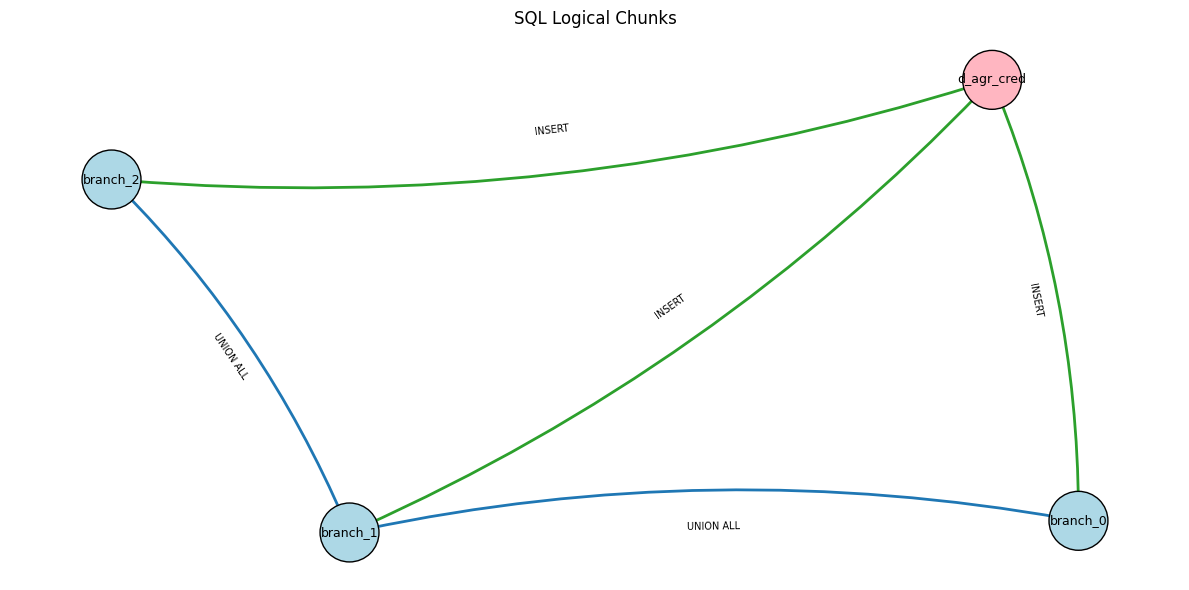

In [7]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.readwrite import json_graph

CHUNK_COLORS = {"target": "#FFB6C1", "cte": "#DDA0DD", "query": "#ADD8E6"}
LINK_COLORS = {"JOIN": "#d62728", "UNION ALL": "#1f77b4", "UNION": "#1f77b4", "INSERT": "#2ca02c"}


def draw_chunks(result, figsize=(12, 6), title="SQL Logical Chunks"):
    node_link = chunk_parser.to_node_link(result)
    graph = json_graph.node_link_graph(node_link, edges="links", directed=True)
    pos = nx.spring_layout(graph, seed=42, k=1.6)

    plt.figure(figsize=figsize)
    colors = [CHUNK_COLORS.get(graph.nodes[n].get("chunk_type", "query"), "#CCCCCC") for n in graph.nodes()]
    nx.draw_networkx_nodes(graph, pos, node_color=colors, node_size=1800, edgecolors="black")

    for link_type in sorted({d.get("link_type", "JOIN") for _, _, d in graph.edges(data=True)}):
        pairs = [(u, v) for u, v, d in graph.edges(data=True) if d.get("link_type") == link_type]
        nx.draw_networkx_edges(
            graph, pos, edgelist=pairs, edge_color=LINK_COLORS.get(link_type, "#7f7f7f"),
            width=2, arrows=True, arrowsize=16, connectionstyle="arc3,rad=0.1",
        )

    labels = {n: graph.nodes[n].get("label", n) for n in graph.nodes()}
    nx.draw_networkx_labels(graph, pos, labels=labels, font_size=9)

    edge_labels = {
        (u, v): d.get("condition") or d.get("link_type", "")
        for u, v, d in graph.edges(data=True)
    }
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=7)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


active = result if "error" not in result else preparse_result
draw_chunks(active, title="SQL Logical Chunks")

In [8]:
output_path = ROOT / "data" / "sql_chunk_result.json"
active = result if "error" not in result else preparse_result

payload = {
    "chunks": active.get("chunks", []),
    "links": active.get("links", []),
}
output_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
print(f"Saved to {output_path}")
print(f"{len(payload['chunks'])} chunks, {len(payload['links'])} links")

Saved to /Users/nikolajabramov/PycharmProjects/llm4lineage/data/sql_chunk_result.json
4 chunks, 5 links


{
  "chunks": [
    {
      "id": "recent_orders",
      "name": "recent_orders",
      "chunk_type": "cte",
      "sql": "SELECT customer_id, SUM(amount) AS total FROM orders WHERE order_date > '2025-01-01' GROUP BY customer_id"
    },
    {
      "id": "main",
      "name": "main",
      "chunk_type": "query",
      "sql": "SELECT c.name, CASE WHEN c.vip THEN 'VIP' ELSE 'REG' END AS tier, r.total FROM customers AS c JOIN recent_orders AS r ON c.id = r.customer_id WHERE c.active = TRUE"
    }
  ],
  "links": [
    {
      "source": "main",
      "target": "recent_orders",
      "link_type": "JOIN",
      "condition": "customers.id = recent_orders.customer_id"
    }
  ],
  "statement_type": "select",
  "target_table": null,
  "metadata": {
    "source_sql_hash": "e40e31badef515bcb18121565192d269424101307431f35c812d26d812b8a0df",
    "generated_at": "2026-07-24T07:49:31.975901+00:00",
    "seed_source": "sqlglot",
    "pipeline_stage": "deterministic"
  },
  "warnings": []
}


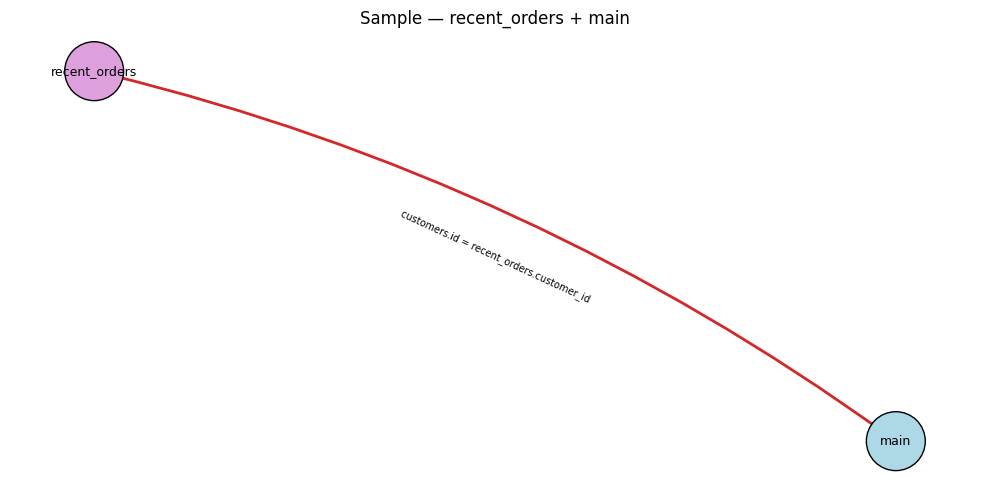

In [9]:
# Sample: CTE + main query with JOIN link
sample_sql = """
WITH recent_orders AS (
    SELECT customer_id, SUM(amount) AS total
    FROM orders
    WHERE order_date > '2025-01-01'
    GROUP BY customer_id
)
SELECT c.name,
    CASE WHEN c.vip THEN 'VIP' ELSE 'REG' END AS tier,
    r.total
FROM customers c
JOIN recent_orders r ON c.id = r.customer_id
WHERE c.active = true
""".strip()

sample_result = chunk_parser.preparse(sample_sql)
print(json.dumps(sample_result, indent=2))
draw_chunks(sample_result, figsize=(10, 5), title="Sample — recent_orders + main")